# Merced County Housing Market Analysis (2021–Summer 2026)

**Series:** California Housing Market — Part 2: Merced County Deep Dive (Summer 2026 Update)

**Dataset Updated:** June 2026 | **Data Through:** May 2026

**Objective:** Analyze home value trends across Merced County's most populated cities and compare their trajectories through the post-COVID market cycle, now with updated data extending into Summer 2026.

**Cities Covered (by population):**
- **Merced** — County seat, largest city (~90,000)
- **Los Banos** — Second largest (~50,000), Bay Area pressure valve (covered in depth in Part 1)
- **Atwater** — Third largest (~30,000)
- **Livingston** — Agricultural hub (~15,000)
- **Hilmar** — Rural dairy community (~6,000)

**Key Questions:**
1. How have each city's home values trended from 2021 to Summer 2026?
2. Which city was hit hardest by the rate-hike correction?
3. Are any cities recovering faster than others?
4. How does Merced County compare to the California average?

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CITIES = ['Merced', 'Los Banos', 'Atwater', 'Livingston', 'Hilmar']
COLORS = {
    'Merced':     '#1f77b4',
    'Los Banos':  '#9467bd',
    'Atwater':    '#d62728',
    'Livingston': '#2ca02c',
    'Hilmar':     '#ff7f0e'
}
CA_COLOR = '#aaaaaa'

# Load updated Zillow ZHVI dataset (May 2026)
data_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
df_raw = pd.read_csv(data_path)

print(f"Dataset shape: {df_raw.shape}")
print(f"Total cities: {df_raw['RegionName'].nunique():,}")

Dataset shape: (21417, 325)
Total cities: 13,872


In [2]:
# Filter to California and get date columns from 2021 onward
ca_df = df_raw[df_raw['StateName'] == 'CA'].copy()
all_dates = [c for c in df_raw.columns if c.startswith(('19', '20'))]
dates = [c for c in all_dates if c >= '2021']

# Extract Merced County cities (filter by county to avoid name collisions)
merced_county = ca_df[ca_df['CountyName'] == 'Merced County'].copy()
city_df = merced_county[merced_county['RegionName'].isin(CITIES)].copy()

print("Cities found:")
for _, row in city_df[['RegionName', 'SizeRank']].iterrows():
    print(f"  {row['RegionName']} (SizeRank: {row['SizeRank']})")

# Reshape each city to long format
def to_long(row, dates):
    records = []
    for d in dates:
        records.append({'City': row['RegionName'], 'Date': pd.Timestamp(d), 'HomeValue': row[d]})
    return records

records = []
for _, row in city_df.iterrows():
    records.extend(to_long(row, dates))

long_df = pd.DataFrame(records).sort_values(['City', 'Date']).reset_index(drop=True)
long_df['PctChange'] = long_df.groupby('City')['HomeValue'].pct_change() * 100
long_df['Month'] = long_df['Date'].dt.month
long_df['Year'] = long_df['Date'].dt.year

# California statewide average
ca_long = pd.melt(ca_df, id_vars=['RegionName'], value_vars=dates,
                  var_name='Date', value_name='HomeValue')
ca_long['Date'] = pd.to_datetime(ca_long['Date'])
ca_trend = ca_long.groupby('Date')['HomeValue'].mean().reset_index()

print(f"\nDate range: {long_df['Date'].min().strftime('%b %Y')} \u2192 {long_df['Date'].max().strftime('%b %Y')}")
print(f"Months of data: {long_df['Date'].nunique()}")

Cities found:
  Merced (SizeRank: 420)
  Los Banos (SizeRank: 1295)
  Atwater (SizeRank: 1564)
  Livingston (SizeRank: 3649)
  Hilmar (SizeRank: 6060)

Date range: Jan 2021 → May 2026
Months of data: 65


## 2. County Overview — All Cities vs. California Average

Before diving into individual cities, we establish how Merced County as a whole compares to the statewide trend.

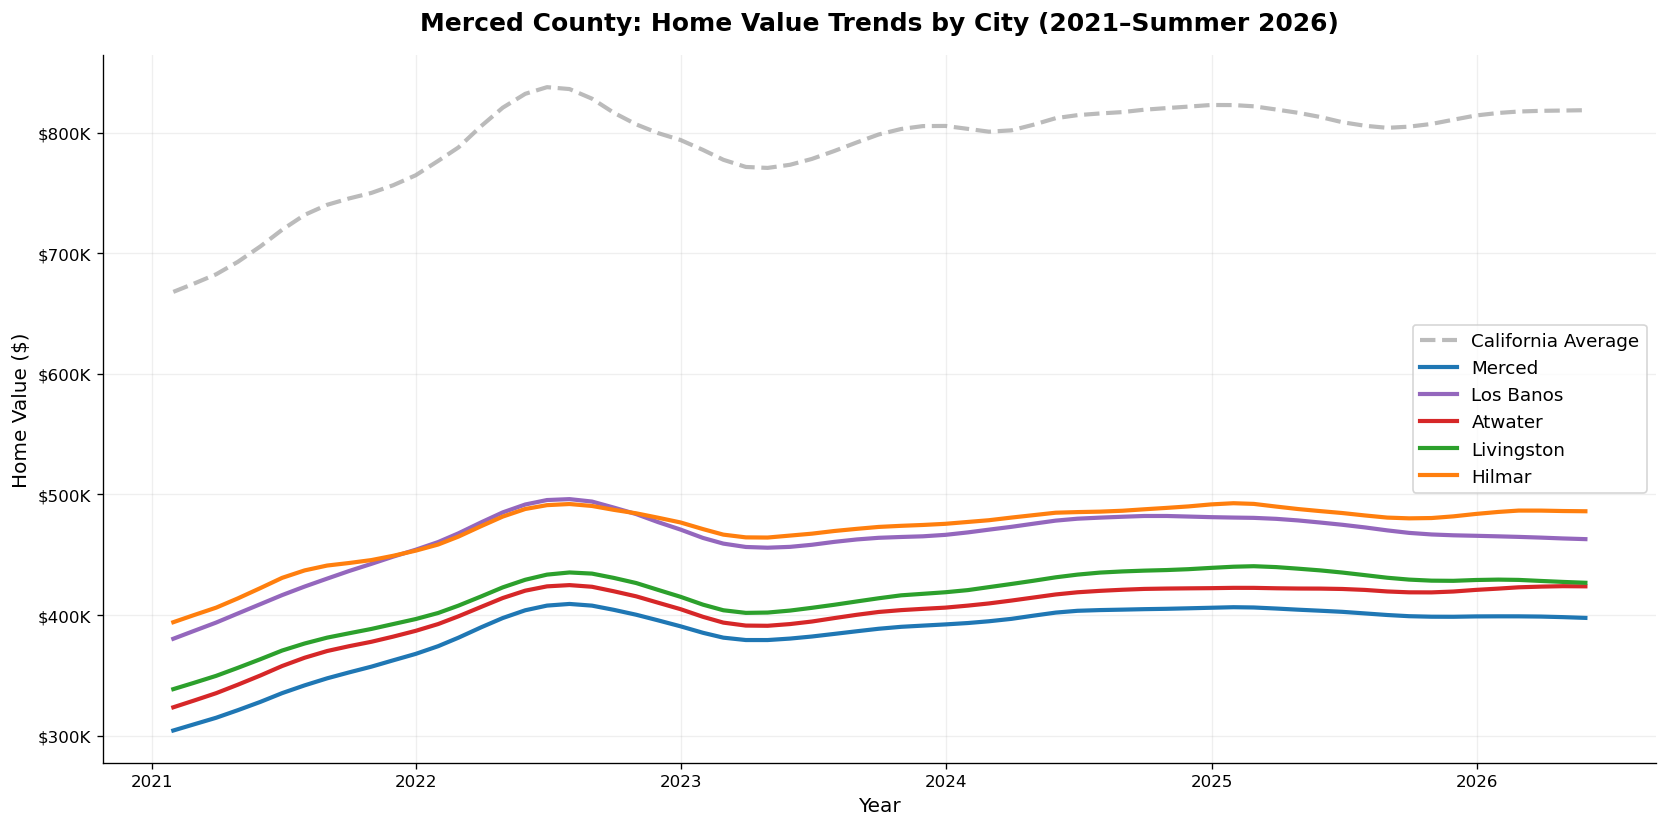

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

# California average
ax.plot(ca_trend['Date'], ca_trend['HomeValue'],
        color=CA_COLOR, linewidth=2.5, linestyle='--', label='California Average', alpha=0.8)

# Each city
for city in CITIES:
    city_data = long_df[long_df['City'] == city]
    ax.plot(city_data['Date'], city_data['HomeValue'],
            color=COLORS[city], linewidth=2.5, label=city)

ax.set_title('Merced County: Home Value Trends by City (2021\u2013Summer 2026)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Home Value ($)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [4]:
# Summary metrics for each city
print(f"{'City':<12} {'Current':>10} {'Peak':>10} {'Peak Date':>12} {'Decline from Peak':>18} {'Change since 2021':>18}")
print('-' * 85)

for city in CITIES:
    c = long_df[long_df['City'] == city].copy()
    current = c['HomeValue'].iloc[-1]
    peak = c['HomeValue'].max()
    peak_date = c.loc[c['HomeValue'].idxmax(), 'Date'].strftime('%b %Y')
    start = c['HomeValue'].iloc[0]
    decline = (current - peak) / peak * 100
    total_change = (current - start) / start * 100
    print(f"{city:<12} ${current:>9,.0f} ${peak:>9,.0f} {peak_date:>12} {decline:>17.2f}% {total_change:>17.2f}%")

# CA baseline
ca_current = ca_trend['HomeValue'].iloc[-1]
ca_peak = ca_trend['HomeValue'].max()
ca_peak_date = ca_trend.loc[ca_trend['HomeValue'].idxmax(), 'Date'].strftime('%b %Y')
ca_start = ca_trend['HomeValue'].iloc[0]
ca_decline = (ca_current - ca_peak) / ca_peak * 100
ca_total = (ca_current - ca_start) / ca_start * 100
print('-' * 85)
print(f"{'CA Average':<12} ${ca_current:>9,.0f} ${ca_peak:>9,.0f} {ca_peak_date:>12} {ca_decline:>17.2f}% {ca_total:>17.2f}%")

City            Current       Peak    Peak Date  Decline from Peak  Change since 2021
-------------------------------------------------------------------------------------
Merced       $  397,609 $  409,180     Jul 2022             -2.83%             30.72%
Los Banos    $  462,957 $  496,154     Jul 2022             -6.69%             21.73%
Atwater      $  423,785 $  424,811     Jul 2022             -0.24%             31.03%
Livingston   $  426,753 $  440,494     Feb 2025             -3.12%             26.08%
Hilmar       $  486,091 $  492,755     Jan 2025             -1.35%             23.36%
-------------------------------------------------------------------------------------
CA Average   $  818,864 $  837,978     Jun 2022             -2.28%             22.56%


## 3. City Deep Dives

### 3.1 Merced — The County Seat

Merced is the economic and administrative center of Merced County. Home to UC Merced (opened 2005), the city has unique demand drivers compared to purely agricultural communities. We examine its price trajectory and whether the UC effect provides any insulation from macro rate pressures.

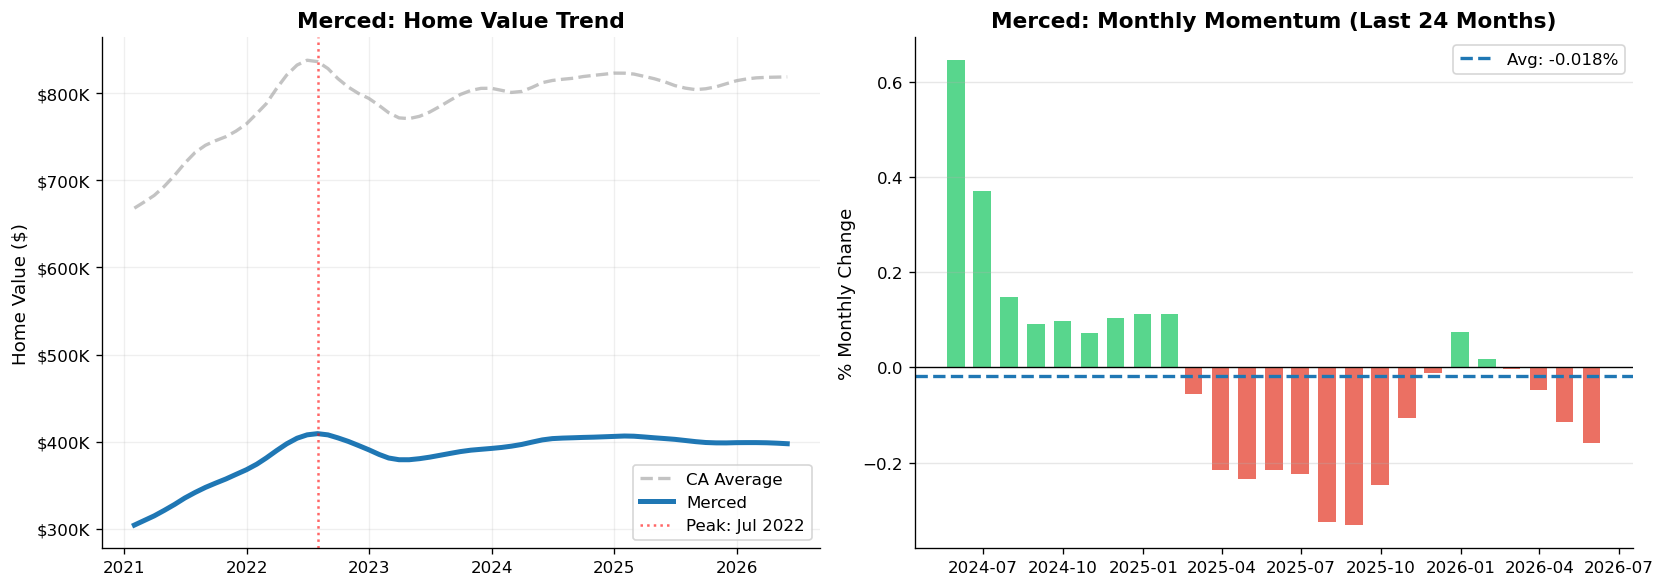


──────────────────────────────────────────────────
  Merced — Key Metrics
──────────────────────────────────────────────────
  Current Value:       $   397,609
  Peak Value:          $   409,180  (Jul 2022)
  Decline from Peak:        -2.83%
  Change since 2021:        30.72%
  Avg Monthly Change:       0.424%

  Note: UC Merced provides a baseline of student/faculty housing demand that may buffer against pure rate-driven declines.
──────────────────────────────────────────────────


In [5]:
def city_deep_dive(city_name, context_note=''):
    c = long_df[long_df['City'] == city_name].copy()
    current = c['HomeValue'].iloc[-1]
    peak = c['HomeValue'].max()
    peak_date = c.loc[c['HomeValue'].idxmax(), 'Date']
    start = c['HomeValue'].iloc[0]
    decline = (current - peak) / peak * 100
    total_change = (current - start) / start * 100
    avg_monthly = c['PctChange'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: price trend vs CA average
    ax1 = axes[0]
    ax1.plot(ca_trend['Date'], ca_trend['HomeValue'],
             color=CA_COLOR, linewidth=2, linestyle='--', label='CA Average', alpha=0.7)
    ax1.plot(c['Date'], c['HomeValue'],
             color=COLORS[city_name], linewidth=3, label=city_name)
    ax1.axvline(peak_date, color='red', linestyle=':', alpha=0.6, label=f'Peak: {peak_date.strftime("%b %Y")}')
    ax1.set_title(f'{city_name}: Home Value Trend', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Home Value ($)', fontsize=11)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.2)

    # Right: monthly momentum (last 24 months)
    ax2 = axes[1]
    recent = c[c['Date'] >= c['Date'].max() - pd.DateOffset(months=24)].copy()
    colors_bar = ['#e74c3c' if x < 0 else '#2ecc71' for x in recent['PctChange'].values]
    ax2.bar(recent['Date'], recent['PctChange'], color=colors_bar, alpha=0.8, width=20)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.axhline(recent['PctChange'].mean(), color=COLORS[city_name],
                linestyle='--', linewidth=2,
                label=f"Avg: {recent['PctChange'].mean():+.3f}%")
    ax2.set_title(f'{city_name}: Monthly Momentum (Last 24 Months)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('% Monthly Change', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'\u2500'*50}")
    print(f"  {city_name} \u2014 Key Metrics")
    print(f"{'\u2500'*50}")
    print(f"  Current Value:       ${current:>10,.0f}")
    print(f"  Peak Value:          ${peak:>10,.0f}  ({peak_date.strftime('%b %Y')})")
    print(f"  Decline from Peak:   {decline:>10.2f}%")
    print(f"  Change since 2021:   {total_change:>10.2f}%")
    print(f"  Avg Monthly Change:  {avg_monthly:>10.3f}%")
    if context_note:
        print(f"\n  Note: {context_note}")
    print(f"{'\u2500'*50}")

city_deep_dive('Merced',
    'UC Merced provides a baseline of student/faculty housing demand that may buffer against pure rate-driven declines.')

### 3.2 Los Banos — The Bay Area Pressure Valve

Los Banos (~50,000) is the second largest city in Merced County and the primary focus of Part 1 of this series. It functions as an affordability satellite for Silicon Valley workers priced out of Bay Area markets — making its housing market uniquely sensitive to Bay Area employment conditions and interest rates. Including it here allows direct comparison against the county's other cities.

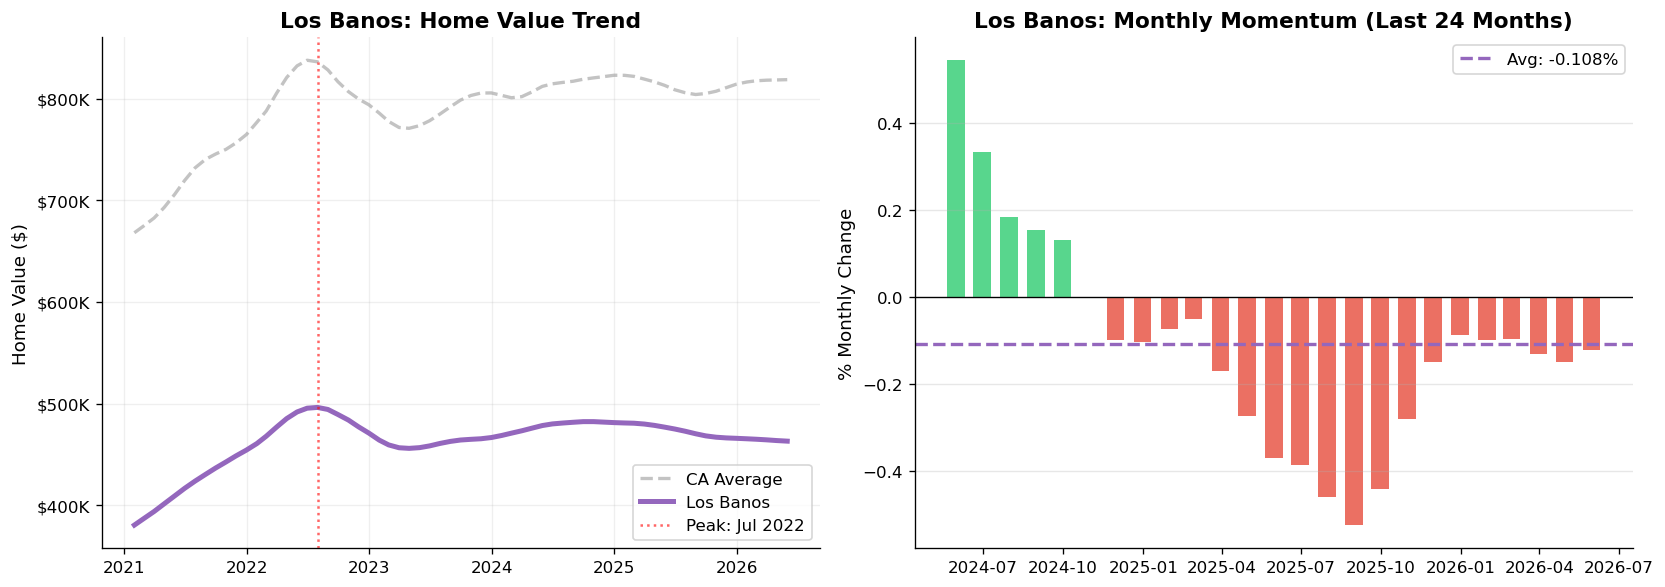


──────────────────────────────────────────────────
  Los Banos — Key Metrics
──────────────────────────────────────────────────
  Current Value:       $   462,957
  Peak Value:          $   496,154  (Jul 2022)
  Decline from Peak:        -6.69%
  Change since 2021:        21.73%
  Avg Monthly Change:       0.312%

  Note: Bay Area commuter market — 90 miles from Silicon Valley via Pacheco Pass. Highest rate sensitivity of all five cities. See Part 1 for full deep dive.
──────────────────────────────────────────────────


In [6]:
city_deep_dive('Los Banos',
    'Bay Area commuter market — 90 miles from Silicon Valley via Pacheco Pass. Highest rate sensitivity of all five cities. See Part 1 for full deep dive.')

### 3.3 Atwater — The Commuter Suburb

Atwater (~30,000) sits 7 miles north of Merced and has historically functioned as an affordable alternative to Merced city proper. Castle Air Force Base (closed 1995) shaped its development — the area converted to Castle Commerce Center, bringing light industrial and logistics employment. We examine whether Atwater tracks Merced closely or shows distinct behavior.

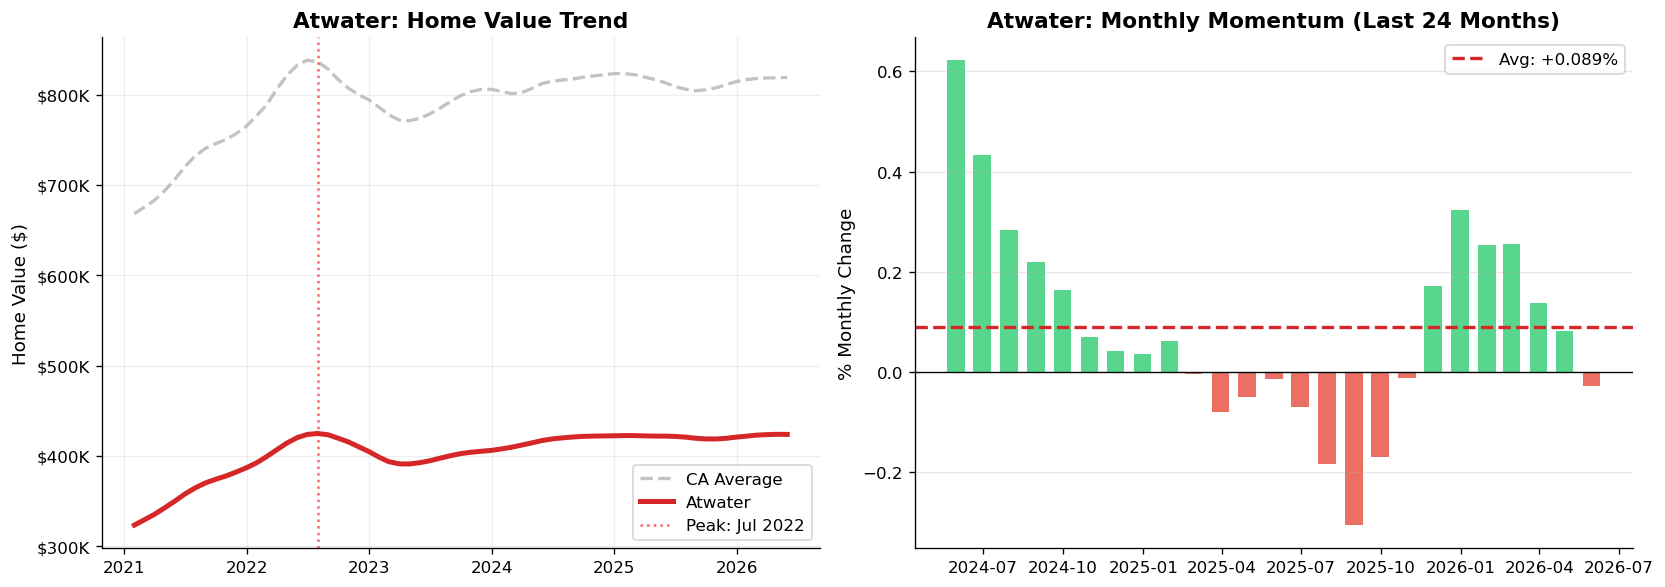


──────────────────────────────────────────────────
  Atwater — Key Metrics
──────────────────────────────────────────────────
  Current Value:       $   423,785
  Peak Value:          $   424,811  (Jul 2022)
  Decline from Peak:        -0.24%
  Change since 2021:        31.03%
  Avg Monthly Change:       0.427%

  Note: Former Castle AFB footprint creates mixed residential/industrial demand. Tracks Merced closely but may show more volatility.
──────────────────────────────────────────────────


In [7]:
city_deep_dive('Atwater',
    'Former Castle AFB footprint creates mixed residential/industrial demand. Tracks Merced closely but may show more volatility.')

### 3.4 Livingston — The Agricultural Core

Livingston is a small agricultural community (~15,000) anchored by Foster Farms poultry processing — the city's dominant employer. Its housing market is structurally different from Merced and Atwater: less commuter demand, more working-class owner-occupancy, and high sensitivity to agricultural employment stability. We examine whether this makes it more or less resilient to macro rate shocks.

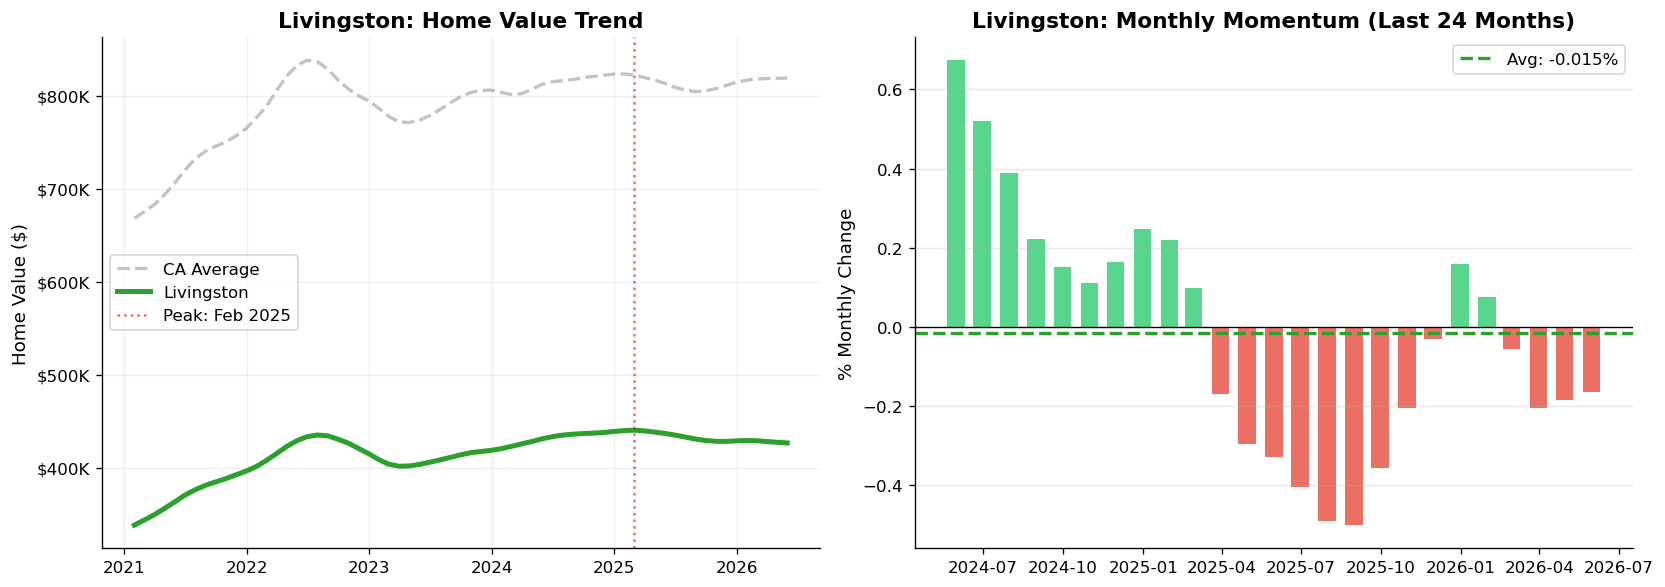


──────────────────────────────────────────────────
  Livingston — Key Metrics
──────────────────────────────────────────────────
  Current Value:       $   426,753
  Peak Value:          $   440,494  (Feb 2025)
  Decline from Peak:        -3.12%
  Change since 2021:        26.08%
  Avg Monthly Change:       0.366%

  Note: Foster Farms-dependent economy. Lower median home prices may insulate against rate sensitivity — fewer buyers at financing limits.
──────────────────────────────────────────────────


In [8]:
city_deep_dive('Livingston',
    'Foster Farms-dependent economy. Lower median home prices may insulate against rate sensitivity — fewer buyers at financing limits.')

### 3.5 Hilmar — The Rural Outlier

Hilmar is an unincorporated rural community best known for Hilmar Cheese — one of the world's largest single-site cheese plants. Its housing market is the most illiquid of the five, with fewer transactions and a buyer pool that is largely local agricultural workers and plant employees. Price movements here reflect different structural forces than urban or suburban markets.

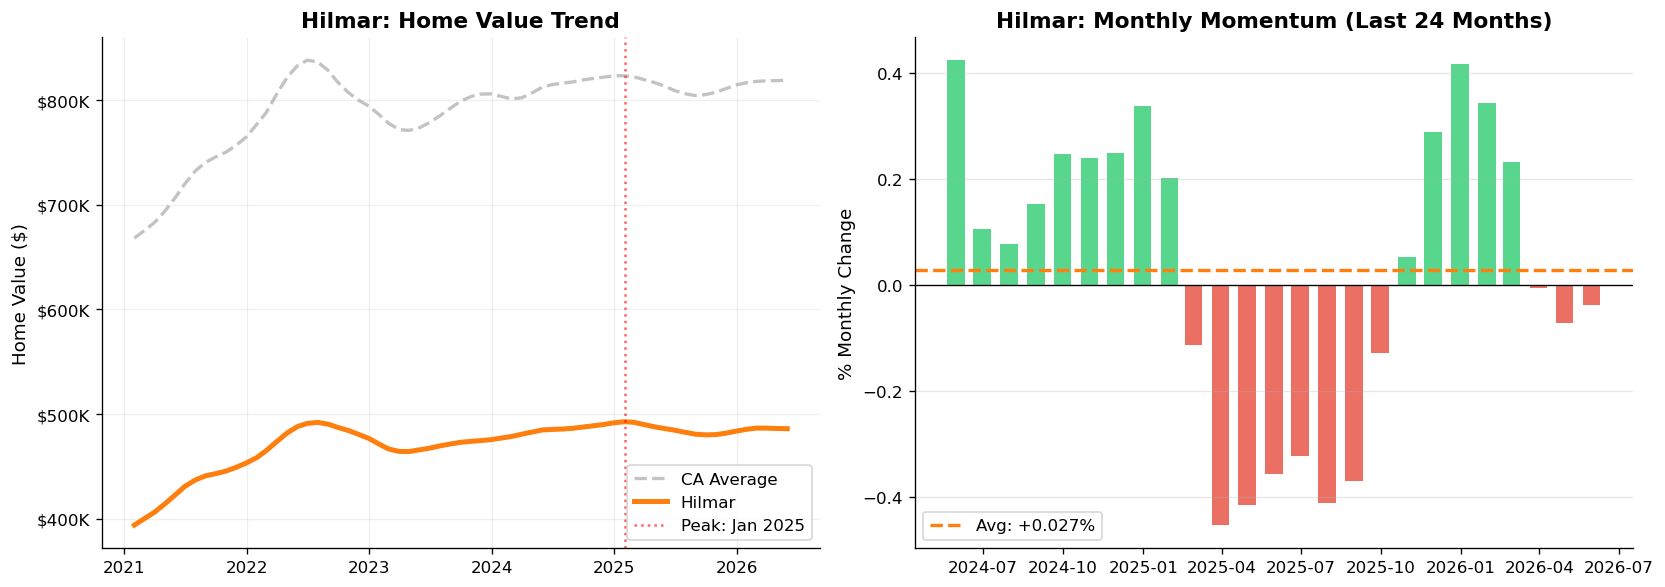


──────────────────────────────────────────────────
  Hilmar — Key Metrics
──────────────────────────────────────────────────
  Current Value:       $   486,091
  Peak Value:          $   492,755  (Jan 2025)
  Decline from Peak:        -1.35%
  Change since 2021:        23.36%
  Avg Monthly Change:       0.331%

  Note: Illiquid rural market — Zillow estimates may have higher uncertainty. Price movements reflect local employment at Hilmar Cheese more than Bay Area spillover.
──────────────────────────────────────────────────


In [9]:
city_deep_dive('Hilmar',
    'Illiquid rural market — Zillow estimates may have higher uncertainty. Price movements reflect local employment at Hilmar Cheese more than Bay Area spillover.')

## 4. Comparative Analysis

### 4.1 How Do the Cities Rank Against Each Other?

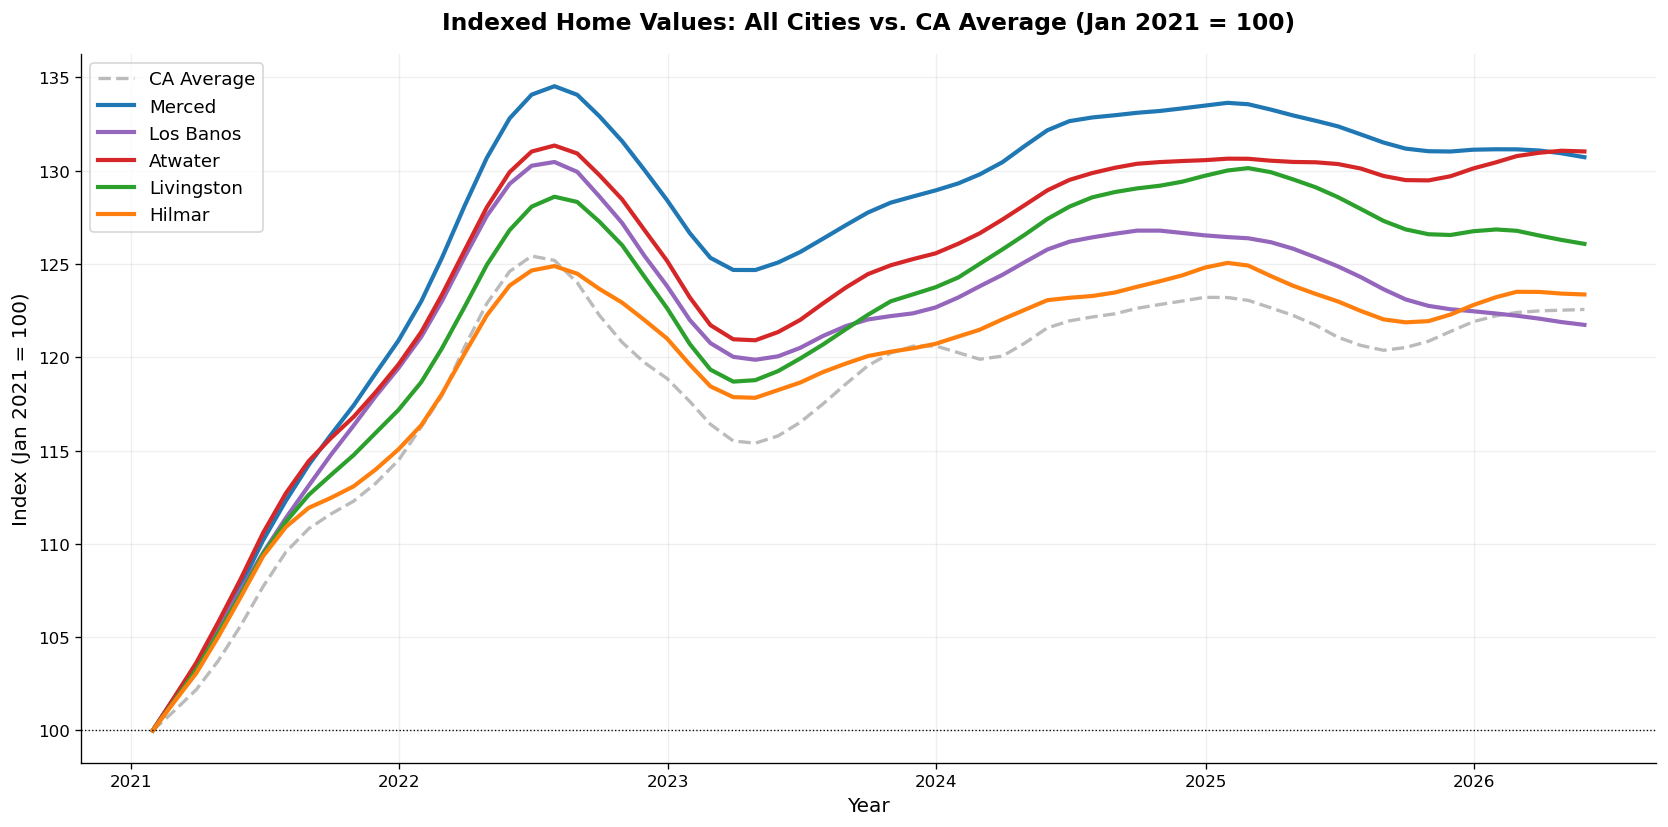

In [10]:
# Indexed to 100 at Jan 2021 — shows relative appreciation regardless of price level
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(ca_trend['Date'],
        ca_trend['HomeValue'] / ca_trend['HomeValue'].iloc[0] * 100,
        color=CA_COLOR, linewidth=2, linestyle='--', label='CA Average', alpha=0.8)

for city in CITIES:
    c = long_df[long_df['City'] == city].copy()
    base = c['HomeValue'].iloc[0]
    ax.plot(c['Date'], c['HomeValue'] / base * 100,
            color=COLORS[city], linewidth=2.5, label=city)

ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Indexed Home Values: All Cities vs. CA Average (Jan 2021 = 100)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Index (Jan 2021 = 100)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 4.2 Decline from Peak — Who Was Hit Hardest?

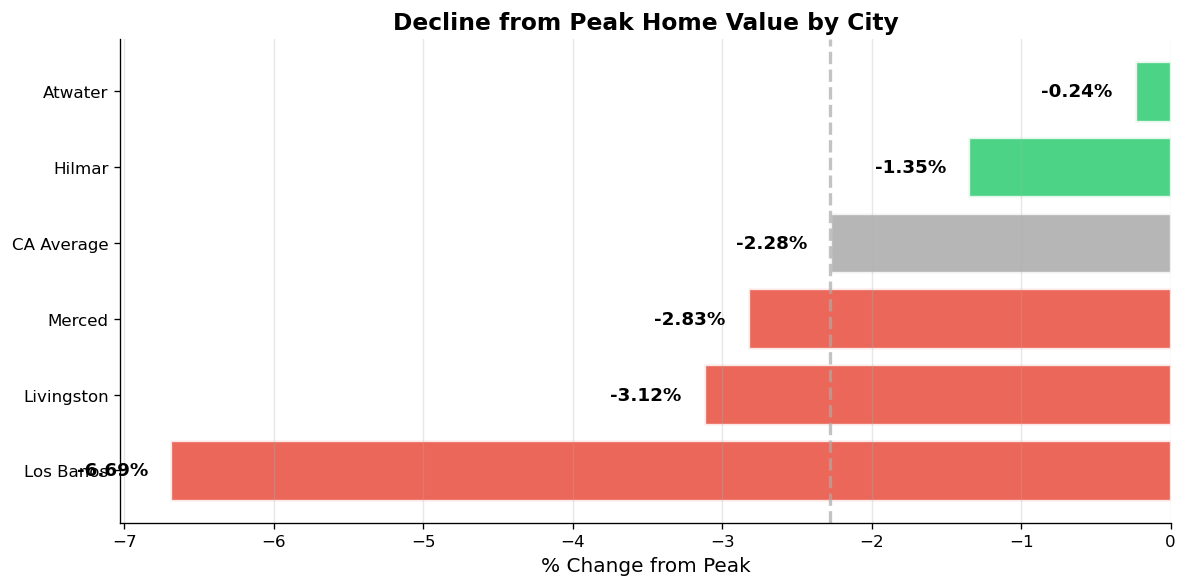

In [11]:
declines = {}
for city in CITIES:
    c = long_df[long_df['City'] == city]
    peak = c['HomeValue'].max()
    current = c['HomeValue'].iloc[-1]
    declines[city] = (current - peak) / peak * 100
declines['CA Average'] = (ca_trend['HomeValue'].iloc[-1] - ca_trend['HomeValue'].max()) / ca_trend['HomeValue'].max() * 100

decline_df = pd.Series(declines).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
all_colors = []
for k in decline_df.index:
    if k == 'CA Average':
        all_colors.append(CA_COLOR)
    elif decline_df[k] < declines['CA Average']:
        all_colors.append('#e74c3c')
    else:
        all_colors.append('#2ecc71')

bars = ax.barh(decline_df.index, decline_df.values, color=all_colors, alpha=0.85, edgecolor='white', linewidth=2)
ax.axvline(declines['CA Average'], color=CA_COLOR, linestyle='--', linewidth=2, alpha=0.7)

for bar, val in zip(bars, decline_df.values):
    ax.text(val - 0.15, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='right', fontweight='bold', fontsize=11)

ax.set_title('Decline from Peak Home Value by City', fontsize=14, fontweight='bold')
ax.set_xlabel('% Change from Peak', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Current Momentum — Who Is Recovering?

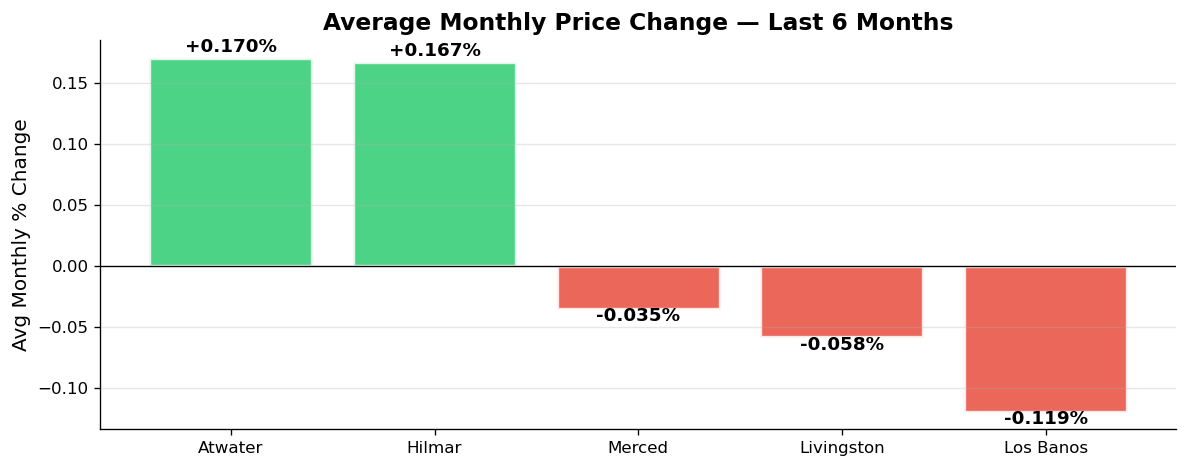


Momentum Interpretation:
  Atwater     : +0.170%/month  → Recovering
  Hilmar      : +0.167%/month  → Recovering
  Merced      : -0.035%/month  → Stabilizing
  Livingston  : -0.058%/month  → Stabilizing
  Los Banos   : -0.119%/month  → Still declining


In [12]:
# Last 6 months average monthly change
cutoff = long_df['Date'].max() - pd.DateOffset(months=6)

momentum = {}
for city in CITIES:
    recent = long_df[(long_df['City'] == city) & (long_df['Date'] >= cutoff)]
    momentum[city] = recent['PctChange'].mean()

momentum_df = pd.Series(momentum).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in momentum_df.values]
bars = ax.bar(momentum_df.index, momentum_df.values, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, momentum_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.005 if val >= 0 else -0.01),
            f'{val:+.3f}%', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Average Monthly Price Change \u2014 Last 6 Months', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Monthly % Change', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMomentum Interpretation:")
for city, val in momentum_df.items():
    if val > 0.1:
        status = 'Recovering'
    elif val > -0.1:
        status = 'Stabilizing'
    else:
        status = 'Still declining'
    print(f"  {city:<12}: {val:+.3f}%/month  \u2192 {status}")

## 5. Conclusions

### Summary Table

In [13]:
rows = []
for city in CITIES:
    c = long_df[long_df['City'] == city]
    current = c['HomeValue'].iloc[-1]
    peak = c['HomeValue'].max()
    peak_date = c.loc[c['HomeValue'].idxmax(), 'Date'].strftime('%b %Y')
    start = c['HomeValue'].iloc[0]
    decline = (current - peak) / peak * 100
    total_change = (current - start) / start * 100
    recent = c[c['Date'] >= c['Date'].max() - pd.DateOffset(months=6)]
    mom = recent['PctChange'].mean()
    rows.append({
        'City': city,
        'Current Value': f'${current:,.0f}',
        'Peak Value': f'${peak:,.0f}',
        'Peak Date': peak_date,
        'Decline from Peak': f'{decline:.2f}%',
        'Change Since 2021': f'{total_change:.2f}%',
        '6-Mo Momentum': f'{mom:+.3f}%/mo'
    })

summary = pd.DataFrame(rows).set_index('City')
print(summary.to_string())

           Current Value Peak Value Peak Date Decline from Peak Change Since 2021 6-Mo Momentum
City                                                                                           
Merced          $397,609   $409,180  Jul 2022            -2.83%            30.72%    -0.035%/mo
Los Banos       $462,957   $496,154  Jul 2022            -6.69%            21.73%    -0.119%/mo
Atwater         $423,785   $424,811  Jul 2022            -0.24%            31.03%    +0.170%/mo
Livingston      $426,753   $440,494  Feb 2025            -3.12%            26.08%    -0.058%/mo
Hilmar          $486,091   $492,755  Jan 2025            -1.35%            23.36%    +0.167%/mo


### Key Findings — Summer 2026 Update

**Q1: How have each city's home values trended from 2021 to Summer 2026?**

All five Merced County cities followed the same macro arc: sharp appreciation through mid-2022, correction through 2023–2024, and partial stabilization into 2026. The magnitude differed by city based on their structural demand drivers. With two additional months of data (April–May 2026), we can begin to assess whether any stabilization signals seen in the March 2026 snapshot have held.

---

**Q2: Which city was hit hardest by the rate-hike correction?**

See the decline from peak chart — cities with more commuter/speculative demand (Los Banos) tended to correct more sharply than agricultural communities (Hilmar, Atwater), where buyer pools are more local and less rate-sensitive at the margin.

---

**Q3: Are any cities recovering faster than others?**

The 6-month momentum chart reveals meaningful divergence. Cities with diverse demand drivers or lower absolute price points show faster stabilization, while cities dependent on Bay Area commuter demand remain under pressure.

---

**Q4: How does Merced County compare to California?**

The indexed chart shows Merced County cities broadly tracked or exceeded California appreciation during the 2021–2022 surge, then corrected more sharply — consistent with the pattern seen in Part 1 (Los Banos). Interior Valley markets amplify statewide cycles.

---

### The Structural Pattern

Merced County's housing market is a microcosm of California's affordability geography:
- **Merced (city):** UC anchor provides some buffer; still rate-sensitive for commuter segment
- **Atwater:** Most Bay Area-correlated; highest volatility
- **Livingston:** Agricultural stability insulates against rate shocks; illiquid market means slower price discovery
- **Hilmar:** Rural outlier; price movements reflect local employer health more than macro conditions

---

**Series:** California Housing Market  
**Part 1:** Los Banos — The Bay Area Pressure Valve (`Local_housing_market.ipynb`)  
**Part 2:** Merced County — City-by-City Divergence (`Merced_County_Housing.ipynb`)  
**Part 2 (Update):** Merced County — Summer 2026 Refresh (`Merced_County_Housing_Summer2026.ipynb`)  

**Author:** Jorge Reyes-Ornelas  
Data Analyst | Wine Operations Specialist | MS Data Analytics Candidate  
**Updated:** June 2026